### Importation d'image avec plan

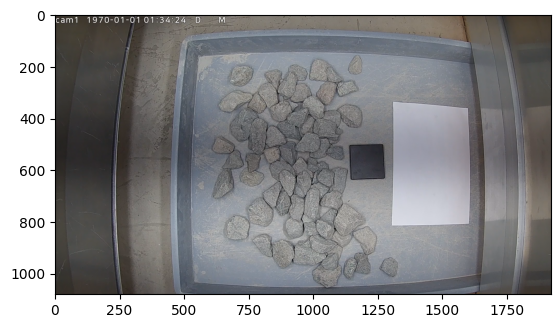

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('D:\\profilometre\\Etude de ballast\\courbe de granulometerie\\ajustement cam\\homographie\\img homographie\\img plan 1.png')

rgb_img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(rgb_img)


### Correction de distortion

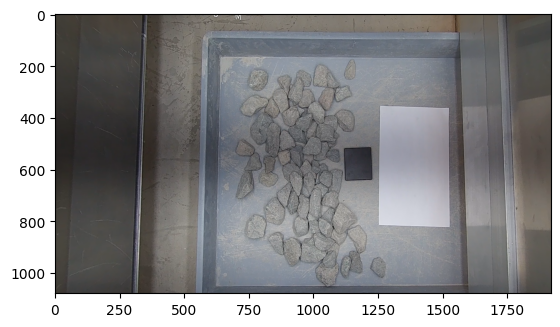

In [2]:
data = np.load("camera_params.npz")
mtx = data['mtx']
dist = data['dist']

h,  w = img.shape[:2]
newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w,h), 0, (w,h))

# undistort
dst = cv.undistort(img, mtx, dist, None, newcameramtx)

# crop the image
x, y, w, h = roi
dst = dst[y:y+h, x:x+w]

plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))

### Definition du plan sur image

Coins détectés : [[1255  355]
 [1250  814]
 [1523  823]
 [1521  363]]


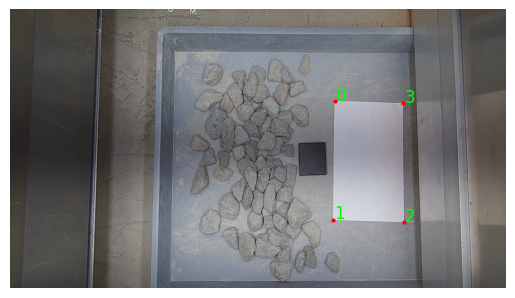

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Supposons que dst soit ton image
gray = cv2.cvtColor(dst, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

# Trouver les contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

page_corners = None

for cnt in contours:
    epsilon = 0.02 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    if len(approx) == 4:
        page_corners = approx.reshape(4, 2)
        break

print("Coins détectés :", page_corners)

# --- Affichage avec Matplotlib ---
fig, ax = plt.subplots()
# Convertir BGR -> RGB pour matplotlib
img_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
ax.imshow(img_rgb)

# Dessiner les coins détectés
if page_corners is not None:
    for i, corner in enumerate(page_corners):
        x, y = corner
        ax.plot(x, y, 'ro', markersize=2)  # cercle rouge
        ax.text(x + 5, y - 5, str(i), color='lime', fontsize=12)  # numéro du coin

plt.axis('off')  # enlever les axes
plt.show()


### Correctio homographie et pixel

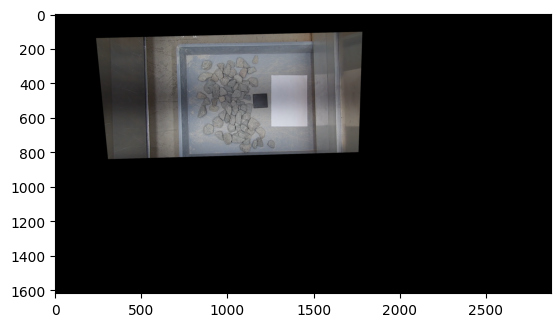

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Image d'entrée

# Quadrilatère à redresser
pts1 = np.float32([page_corners[0] , page_corners[3] , page_corners[1] , page_corners[2]])

# Plan redressé
pts2 = np.float32([[0,0],[209,0],[0,296],[209,296]])

# Matrice de transformation pour redresser le plan
M = cv.getPerspectiveTransform(pts1, pts2)

x_coin_haut_gauche ,  y_coin_haut_gauche = page_corners[0,0] , page_corners[0,1]


T = np.array([
    [1,0, x_coin_haut_gauche],
    [0,1, y_coin_haut_gauche],
    [0,0,1]
], dtype=np.float32)

M2 = T @ M

dst_nouv = cv.warpPerspective(dst, M2, (int(dst.shape[1]*1.5),int(dst.shape[0]*1.5)))

plt.imshow(cv2.cvtColor(dst_nouv, cv2.COLOR_BGR2RGB))
# plt.plot(296, 209, 'ro', markersize=2) 


### Ajustement de la correction

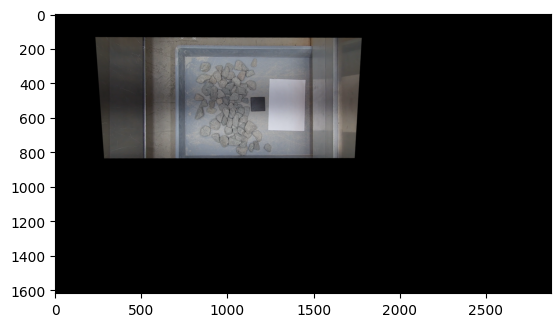

In [10]:

gray = cv.cvtColor(dst_nouv, cv.COLOR_BGR2GRAY)
_, thresh = cv.threshold(gray, 100, 255, cv.THRESH_BINARY)  # seuil faible pour récupérer tout
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# --- Prendre le plus grand contour (la feuille + tout contenu transformé) ---
cnt = max(contours, key=cv.contourArea)

# --- Calcul du minimum area rectangle (rotated rectangle) ---
rect = cv.minAreaRect(cnt)
box = cv.boxPoints(rect)


dx = box[1,0]-box[0,0] # différence en X
dy = box[1,1]-box[0,1]  # différence en Y

angle_rad = np.arctan2(dy, dx)   # angle en radians
angle_deg = np.degrees(angle_rad) # conversion en degrés


M_rot = cv.getRotationMatrix2D((int((dx)/2) , int((dy)/2)) ,angle_deg,1)

dst_nouv_rot = cv.warpAffine(dst_nouv,M_rot,(dst_nouv.shape[1],dst_nouv.shape[0]))

plt.imshow(cv2.cvtColor(dst_nouv_rot, cv2.COLOR_BGR2RGB))




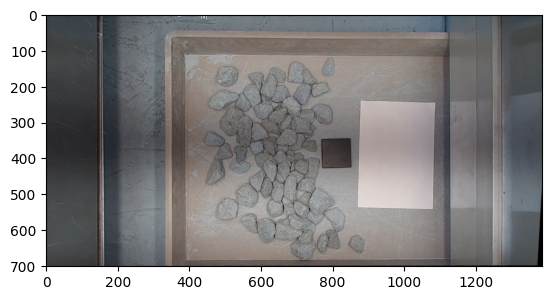

In [11]:
# convertir en gris
gray = cv2.cvtColor(dst_nouv_rot, cv2.COLOR_BGR2GRAY)
mask = gray > 100   # True = pixel non noir

coords = np.argwhere(mask)  # array de shape (N,2) : [ligne, colonne]
y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

cropped = dst_nouv_rot[y_min:y_max+1, x_min:x_max+1]

plt.imshow(cropped)

### Test des matrices sur une autre image

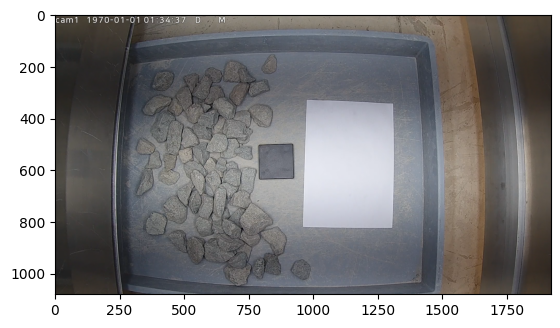

In [12]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('D:\\profilometre\\Etude de ballast\\courbe de granulometerie\\ajustement cam\\homographie\\img homographie\\img plan 2.png')

rgb_img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(rgb_img)


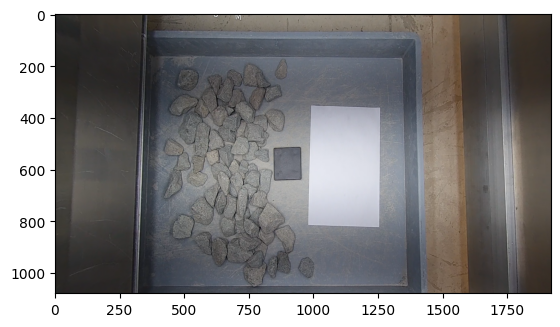

In [13]:
data = np.load("camera_params.npz")
mtx = data['mtx']
dist = data['dist']

h,  w = img.shape[:2]
newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w,h), 0, (w,h))

# undistort
dst = cv.undistort(img, mtx, dist, None, newcameramtx)

# crop the image
x, y, w, h = roi
dst = dst[y:y+h, x:x+w]

plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))

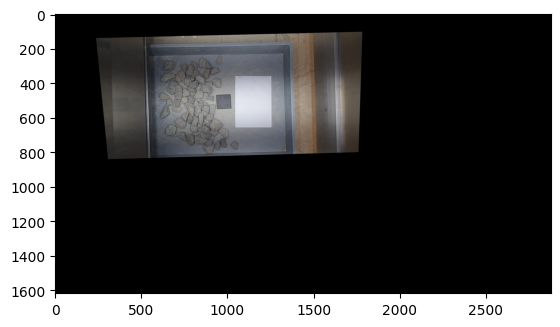

In [14]:
dst_nouv = cv.warpPerspective(dst, M2, (int(dst.shape[1]*1.5),int(dst.shape[0]*1.5)))

plt.imshow(cv2.cvtColor(dst_nouv, cv2.COLOR_BGR2RGB))


In [21]:
angle_deg

np.float32(-1.4688033)

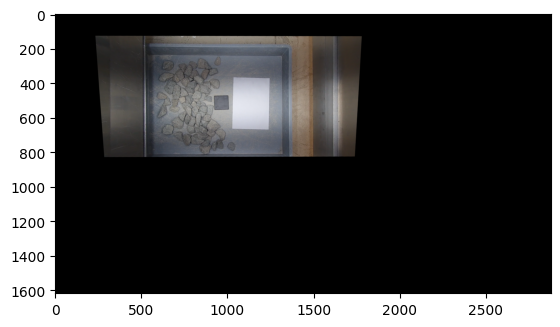

In [16]:

gray = cv.cvtColor(dst_nouv, cv.COLOR_BGR2GRAY)
_, thresh = cv.threshold(gray, 50, 255, cv.THRESH_BINARY)  # seuil faible pour récupérer tout
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# --- Prendre le plus grand contour (la feuille + tout contenu transformé) ---
cnt = max(contours, key=cv.contourArea)

# --- Calcul du minimum area rectangle (rotated rectangle) ---
rect = cv.minAreaRect(cnt)
box = cv.boxPoints(rect)


dx = box[1,0]-box[0,0] # différence en X
dy = box[1,1]-box[0,1]  # différence en Y

angle_rad = np.arctan2(dy, dx)   # angle en radians
angle_deg = np.degrees(angle_rad) # conversion en degrés


M_rot = cv.getRotationMatrix2D((int((dx)/2) , int((dy)/2)) ,angle_deg,1)

dst_nouv_rot = cv.warpAffine(dst_nouv,M_rot,(dst_nouv.shape[1],dst_nouv.shape[0]))

plt.imshow(cv2.cvtColor(dst_nouv_rot, cv2.COLOR_BGR2RGB))




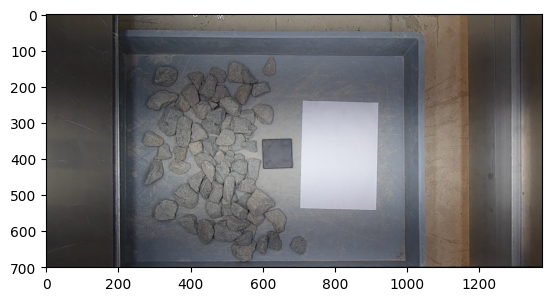

In [18]:
# convertir en gris
gray = cv2.cvtColor(dst_nouv_rot, cv2.COLOR_BGR2GRAY)
mask = gray > 100   # True = pixel non noir

coords = np.argwhere(mask)  # array de shape (N,2) : [ligne, colonne]
y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

cropped = dst_nouv_rot[y_min:y_max+1, x_min:x_max+1]

plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))

Coins détectés : [[712 240]
 [705 537]
 [914 542]
 [921 245]]


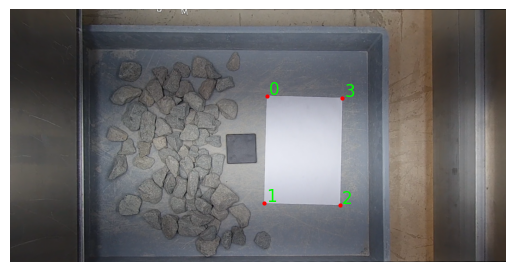

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Supposons que dst soit ton image
gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

# Trouver les contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

page_corners = None

for cnt in contours:
    epsilon = 0.02 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    if len(approx) == 4:
        page_corners = approx.reshape(4, 2)
        break

print("Coins détectés :", page_corners)

# --- Affichage avec Matplotlib ---
fig, ax = plt.subplots()
# Convertir BGR -> RGB pour matplotlib
img_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
ax.imshow(img_rgb)

# Dessiner les coins détectés
if page_corners is not None:
    for i, corner in enumerate(page_corners):
        x, y = corner
        ax.plot(x, y, 'ro', markersize=2)  # cercle rouge
        ax.text(x + 5, y - 5, str(i), color='lime', fontsize=12)  # numéro du coin

plt.axis('off')  # enlever les axes
plt.show()


#### Test des demensions de la feuille detecté

In [20]:
dot_product = np.dot(page_corners[3] - page_corners[0], page_corners[1] - page_corners[0])
print(dot_product)
u = page_corners[2] - page_corners[1]
v = page_corners[2] - page_corners[3]
norm_u = np.linalg.norm(u)
norm_v = np.linalg.norm(v)
print(norm_u)
print(norm_v)

# Cosinus de l'angle
cos_theta = dot_product / (norm_u * norm_v)

# Angle en radians
theta_rad = np.arccos(cos_theta)

# Optionnel : convertir en degrés
theta_deg = np.degrees(theta_rad)

print("Angle en radians :", theta_rad)
print("Angle en degrés :", theta_deg)

22
209.0598000573042
297.0824801296771
Angle en radians : 1.570442105131345
Angle en degrés : 89.9797045936664


### Savegarde des paramètre d'homographi + conversion pixel-mm

In [22]:
import numpy as np

# M = cv.getPerspectiveTransform(...) ou cv.findHomography(...)
np.savez("homography.npz", H=M2)


#Pour charger la matrice plus tard

# data = np.load("homography.npz")
# M_loaded = data["H"]

### Creation des fonctions pour réutilisation

In [26]:
def undistort_img(dist,mtx,cv2_bgr_img):
    h,  w = img.shape[:2]
    newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w,h), 0, (w,h))

    # undistort
    dst = cv.undistort(cv2_bgr_img, mtx, dist, None, newcameramtx)

    # crop the image
    x, y, w, h = roi
    dst = dst[y:y+h, x:x+w]
    return dst


def homo_and_pixel_conversion(cv2_bgr_undistort_img,homo_matrix,thersh_cutting = 100):

    #------------Homography and mm conversion correction-----------------
    
    dst_nouv = cv.warpPerspective(cv2_bgr_undistort_img, homo_matrix, (int(cv2_bgr_undistort_img.shape[1]*1.5),int(cv2_bgr_undistort_img.shape[0]*1.5)))

    #-----------Homography correction ajustement-------------------

    #********rotation_correction*********
    gray = cv.cvtColor(dst_nouv, cv.COLOR_BGR2GRAY)
    _, thresh = cv.threshold(gray, 50, 255, cv.THRESH_BINARY)  # seuil faible pour récupérer tout
    contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    # --- Prendre le plus grand contour (la feuille + tout contenu transformé) ---
    cnt = max(contours, key=cv.contourArea)

    # --- Calcul du minimum area rectangle (rotated rectangle) ---
    rect = cv.minAreaRect(cnt)
    box = cv.boxPoints(rect)

    dx = box[1,0]-box[0,0] # différence en X
    dy = box[1,1]-box[0,1]  # différence en Y

    angle_rad = np.arctan2(dy, dx)   # angle en radians
    angle_deg = np.degrees(angle_rad) # conversion en degrés

    M_rot = cv.getRotationMatrix2D((int((dx)/2) , int((dy)/2)) ,angle_deg,1)

    dst_nouv_rot = cv.warpAffine(dst_nouv,M_rot,(dst_nouv.shape[1],dst_nouv.shape[0]))

    #********cutting correction*********
    # convertir en gris
    gray = cv2.cvtColor(dst_nouv_rot, cv2.COLOR_BGR2GRAY)
    mask = gray > thersh_cutting   # True = pixel non noir

    coords = np.argwhere(mask)  # array de shape (N,2) : [ligne, colonne]
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped = dst_nouv_rot[y_min:y_max+1, x_min:x_max+1]

    return cropped





### Test des fonction 

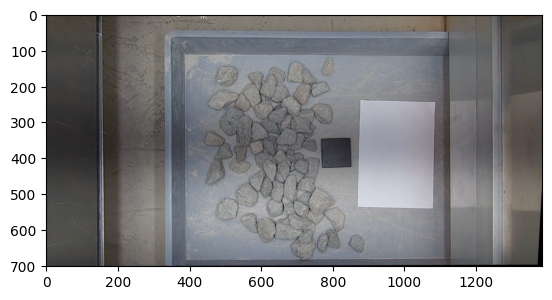

In [32]:
#---------Camera parameters loadings--------------
data = np.load("camera_params.npz")
mtx = data['mtx']
dist = data['dist']

data = np.load("homography.npz")
homo_matrix = data["H"]

#---------Image loading--------------
img = cv.imread('D:\\profilometre\\Etude de ballast\\courbe de granulometerie\\ajustement cam\\homographie\\img homographie\\img plan 1.png')

#--------Image correction-----------
undistort_image= undistort_img(dist,mtx,img)
final_image = homo_and_pixel_conversion(undistort_image,homo_matrix,thersh_cutting = 100)

plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
